
##Standardization

Standardization is a a Feature Scaling Techinque where is shifts and rescale the data points so that each feature have the mean of 0 and StandardDeviation of 1(also called as Zscore Normalization)

Xi=Xi-X^/sd


#Why Use It
####Helps Algorithms Learn Faster:
 Speeds up training for models that use gradient descent, like linear regression or neural networks.
####Prevents Feature Bias:
 Keeps large numbers from dominating smaller numbers during distance calculations.

####Good for Normal Distributions:
  Works best when your input data follows a bell-curve (Gaussian) distribution.



In [18]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

In [35]:
import numpy as np


In [20]:
df=pd.DataFrame({
    'Age': np.random.randint(18,50,20),
    'Salary':np.random.randint(20000,60000,20),
    'Experiecnce':np.random.randint(1,6,20)}
)

In [21]:
df

,Age,Salary,Experiecnce
0,41,34659,5
1,45,25712,1
2,40,44503,3
3,48,38541,5
4,29,28525,4
5,31,37355,3
6,26,59583,1
7,40,43916,3
8,35,56684,1
9,49,33620,4


In [22]:
df.describe()

,Age,Salary,Experiecnce
count,20.000000,20.000000,20.000000
mean,35.000000,41609.500000,2.850000
std,9.915432,10595.583675,1.424411
min,20.000000,25712.000000,1.000000
25%,28.250000,33903.500000,1.000000
50%,33.500000,40798.500000,3.000000
75%,42.000000,47389.500000,4.000000
max,49.000000,59873.000000,5.000000


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [36]:


df


,Age,Salary,Experiecnce,Purchase
0,41,34659,5,1
1,45,25712,1,0
2,40,44503,3,1
3,48,38541,5,1
4,29,28525,4,0
5,31,37355,3,1
6,26,59583,1,1
7,40,43916,3,1
8,35,56684,1,1
9,49,33620,4,1


In [37]:
df["Purchase"] = (
    (df["Salary"] > 30000) &
    (df["Age"] > 25)
).astype(int)

In [38]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchase',axis=1),df['Purchase'],test_size=0.2,random_state=42)

In [39]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((16, 3), (4, 3), (16,), (4,))

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scalar=StandardScaler()

In [30]:
scalar.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [31]:
X_trainscaled=scalar.transform(X_train)
X_testScaled=scalar.transform(X_test)



In [32]:
X_trainscaled=pd.DataFrame(X_trainscaled,columns=X_train.columns)
X_testScaled=pd.DataFrame(X_testScaled,columns=X_test.columns)

In [33]:
X_trainscaled

,Age,Salary,Experiecnce
0,-0.067304,1.279251,-1.477994
1,-0.498048,-0.585337,0.098533
2,-0.498048,0.336973,0.886796
3,1.332616,-0.470928,1.675060
4,-0.390362,-0.725308,0.098533
5,0.578813,-1.541988,-1.477994
6,1.440302,1.150180,-1.477994
7,0.471127,0.104201,0.098533
8,1.440302,-0.945636,0.886796
9,-1.574910,0.225748,0.098533


#SEEING THE DIFFERENCE

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

Text(0.5, 1.0, 'Before SCALING')

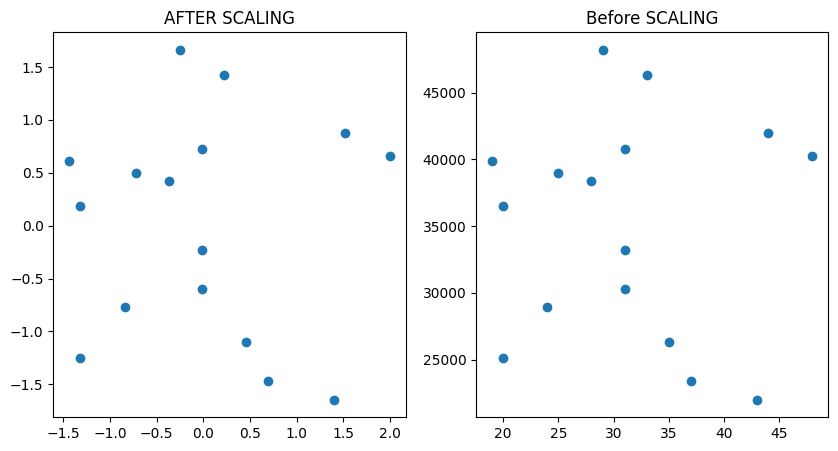

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,5))
ax1.scatter(X_trainscaled['Age'],X_trainscaled['Salary'])
ax1.set_title("AFTER SCALING")
ax2.scatter(X_train['Age'],X_train['Salary'])
ax2.set_title("Before SCALING")


A KDE (Kernel Density Estimate) plot is a chart that shows the shape of a data set's distribution

Text(0.5, 1.0, 'AFTER SCALING')

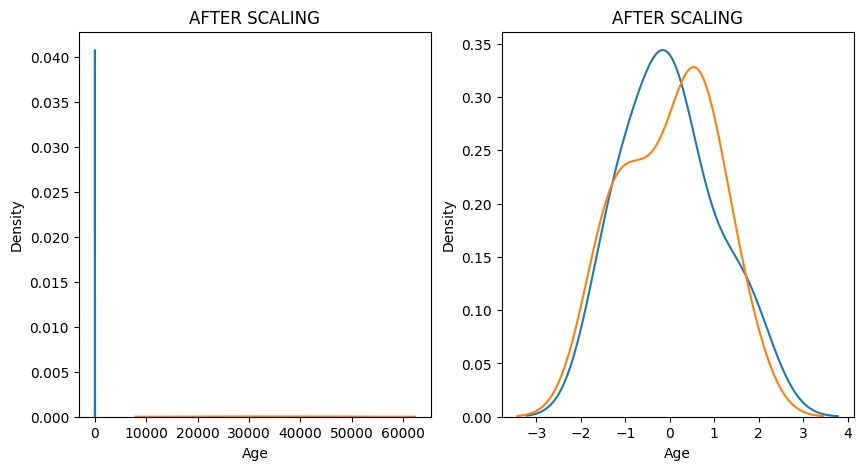

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,5))

ax1.set_title("Before SCALING")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['Salary'],ax=ax1)

ax2.set_title("AFTER SCALING")
sns.kdeplot(X_trainscaled['Age'],ax=ax2)
sns.kdeplot(X_trainscaled['Salary'],ax=ax2)
ax1.set_title("AFTER SCALING")


In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr_scaled=LogisticRegression()



In [ ]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_trainscaled,y_train)



LogisticRegression()

In [ ]:
y_pred=lr.predict(X_test)
y_scaledpred=lr_scaled.predict(X_testScaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(f'before scaling:{accuracy_score(y_test,y_pred)}')
print(f'After Scaling : {accuracy_score(y_test,y_scaledpred)}')

before scaling:1.0
After Scaling : 1.0
